# Counterfactual Impact Evaluation of Renewable Energy Communities (ACC/CER)


## 1. Setup and Configuration

In [1]:
# ============================================================
# 1.1 Auto-install missing dependencies (runs cleanly on first execution)
# ============================================================
import subprocess
import sys

REQUIRED_PACKAGES = ["numpy", "pandas", "scikit-learn", "lightgbm", "xgboost", "scipy", "statsmodels", "matplotlib", "seaborn", "ipython", "geopandas",]

# Function to install missing packages
def _install_if_missing(packages):
    import importlib
    name_map = {"scikit-learn": "sklearn"}
    missing = []
    for pkg in packages:
        mod = name_map.get(pkg, pkg.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print(f"Installing missing packages: {missing}")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", *missing]        )
        print("Installation complete.")
    else:
        print("All required packages already installed.")

_install_if_missing(REQUIRED_PACKAGES)

Installing missing packages: ['ipython']
Installation complete.


In [2]:
# ============================================================
# 1.2 Library imports and global configuration
# ============================================================

import os
import warnings
import unicodedata

import numpy as np
import pandas as pd
import geopandas as gpd

from IPython.display import display, Markdown

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone  

import statsmodels.api as sm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from statsmodels.sandbox.stats.runs import runstest_1samp

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.grid": False,
    "grid.alpha": 0.7,
    "grid.linewidth": 0.6,})

INPUT_DIR = "input"
OUTPUT_DIR = "2_Impact_Analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ALPHA = 0.05

def interpret(p):
    """Return significance label for a p-value."""
    return "significant" if p < ALPHA else "not significant"

print("Libraries loaded.")
print(f"Random seed      : {RANDOM_SEED}")
print(f"Input directory  : {INPUT_DIR}")
print(f"Output directory : {OUTPUT_DIR}")

Libraries loaded.
Random seed      : 42
Input directory  : input
Output directory : 2_Impact_Analysis_output


## 2. Data Ingestion and Horizon Filtering

We load **both** datasets a single time here, coerce numeric columns, and enforce the 12-month horizon constraint on the post-intervention frame: for each parish in `data_after_1acc.csv` we sort chronologically by `date` and retain the first 12 months as the evaluation frame. The training panel `df_before` loaded here is reused directly in Section 3 (no second read of the same file).

In [3]:
# ============================================================
# 2.1 Load raw data ONCE and apply 12-month evaluation horizon
# ============================================================

NUMERIC_COLS = ["energy_kwh", "t2m", "tp"]

df_before = pd.read_csv(f"{INPUT_DIR}/data_before_1acc.csv", parse_dates=["date"])
df_after_raw = pd.read_csv(f"{INPUT_DIR}/data_after_1acc.csv", parse_dates=["date"])

# Coerce numeric columns once, on the single load, so Section 3 can reuse df_before directly
for _col in NUMERIC_COLS:
    if _col in df_before.columns:
        df_before[_col] = pd.to_numeric(df_before[_col], errors="coerce")
    if _col in df_after_raw.columns:
        df_after_raw[_col] = pd.to_numeric(df_after_raw[_col], errors="coerce")

df_before = df_before.sort_values(["parish_code", "date"]).reset_index(drop=True)

print(f"data_before_1acc : {df_before.shape[0]:>7,} rows | "f"{df_before['parish_code'].nunique()} parishes")
print(f"data_after_1acc  : {df_after_raw.shape[0]:>7,} rows | "f"{df_after_raw['parish_code'].nunique()} parishes (raw)")

# Filter to max 12 months per parish in evaluation period
df_after = (df_after_raw.sort_values(["parish_code", "date"]).groupby("parish_code", group_keys=False).head(12).reset_index(drop=True))
assert df_after.groupby("parish_code").size().max() <= 12

n_treatment = df_after.loc[~df_after["control"], "parish_code"].nunique()
n_control   = df_after.loc[ df_after["control"], "parish_code"].nunique()

print(f"\nAfter horizon filter : {df_after.shape[0]:,} rows | "
      f"{df_after['parish_code'].nunique()} parishes")
print(f"Treatment parishes : {n_treatment}")
print(f"Control   parishes : {n_control}")
print(f"Training window    : {df_before['date'].min().date()} -> "
      f"{df_before['date'].max().date()}")
print(f"Evaluation window  : {df_after['date'].min().date()} -> "
      f"{df_after['date'].max().date()}")


data_before_1acc :   7,851 rows | 173 parishes
data_after_1acc  :   2,420 rows | 173 parishes (raw)

After horizon filter : 2,076 rows | 173 parishes
Treatment parishes : 45
Control   parishes : 128
Training window    : 2020-11-01 -> 2024-10-01
Evaluation window  : 2023-08-01 -> 2025-10-01


## 3. Temporal Split & Cross-Validation Setup

This section reuses `df_before` loaded in Section 2. For validation only, the last 12 historical months of each parish are held out as a target window, and the input window is strictly earlier than each parish's own cut-off date. The `ChronoForwardSplit` object is used for parish-level cross-validation diagnostics where a cross-sectional validation design is appropriate. 


In [4]:
# ============================================================
# 3.1 Build parish-level chronological cutoff dates for CV
# ============================================================

CV_FOLDS = 5
TARGET = "energy_kwh"

df_before = df_before.sort_values(["parish_code", "date"]).reset_index(drop=True)

# Each parish's cutoff date is the first month of its last 12 historical months.
# ChronoForwardSplit will order parishes by this date.
cutoff_dates = (
    df_before
    .groupby("parish_code", group_keys=False)
    .tail(12)
    .groupby("parish_code")["date"]
    .min()
    .rename("cutoff_date"))

print(f"Parishes available for ChronoForward CV : {len(cutoff_dates)}")
print(f"Earliest parish cutoff                  : {cutoff_dates.min().date()}")
print(f"Latest parish cutoff                    : {cutoff_dates.max().date()}")

assert cutoff_dates.notna().all(), "Some parishes have missing cutoff dates."

Parishes available for ChronoForward CV : 173
Earliest parish cutoff                  : 2022-08-01
Latest parish cutoff                    : 2023-11-01


In [5]:
# ============================================================
# 3.2 ChronoForward CV for final ensemble diagnostics
# ============================================================

class ChronoForwardSplit:
    """
    Forward-chaining cross-validation over parishes ordered by cutoff date.

    The object expects X to have parish_code values as its index.

    Each fold:
      - trains on parishes with earlier cutoff dates
      - validates on parishes with later cutoff dates

    This is used only for out-of-fold diagnostics of the final ensemble members:
      - Linear Regression
      - Parish Mean
    """

    def __init__(self, cutoff_dates, n_splits=5, min_train_frac=0.50):
        if not 0.0 < min_train_frac < 1.0:
            raise ValueError("min_train_frac must be in (0, 1).")

        self.cutoff_dates = pd.Series(cutoff_dates).copy()
        self.n_splits = int(n_splits)
        self.min_train_frac = float(min_train_frac)

    def split(self, X, y=None, groups=None):
        parishes = pd.Index(X.index).dropna().unique()

        missing = parishes.difference(self.cutoff_dates.index)
        if len(missing) > 0:
            raise ValueError(
                f"{len(missing)} parish_code values are missing from cutoff_dates."
            )

        ordered_parishes = (
            self.cutoff_dates
            .reindex(parishes)
            .sort_values()
            .index
            .to_numpy())

        n = len(ordered_parishes)

        if n < 3:
            raise ValueError("Not enough parishes for ChronoForwardSplit.")

        warmup_n = int(np.floor(n * self.min_train_frac))
        warmup_n = max(1, min(warmup_n, n - 1))

        remaining = n - warmup_n
        test_n = max(1, remaining // self.n_splits)

        fold_id = 0
        start = warmup_n

        while start < n and fold_id < self.n_splits:
            stop = min(start + test_n, n)

            train_parishes = ordered_parishes[:start]
            val_parishes = ordered_parishes[start:stop]

            train_idx = np.where(X.index.isin(train_parishes))[0]
            val_idx = np.where(X.index.isin(val_parishes))[0]

            if len(train_idx) > 0 and len(val_idx) > 0:
                yield train_idx, val_idx

            start = stop
            fold_id += 1

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


def safe_metric(y_true, y_pred, metric="mae"):
    """
    Compute metric while ignoring NaN OOF predictions from the warm-up cohort.
    """
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(yt) & np.isfinite(yp)

    if mask.sum() == 0:
        return float("nan")

    if metric == "rmse":
        return float(np.sqrt(mean_squared_error(yt[mask], yp[mask])))

    return float(mean_absolute_error(yt[mask], yp[mask]))


CV_OUTER = ChronoForwardSplit(
    cutoff_dates=cutoff_dates,
    n_splits=CV_FOLDS,
    min_train_frac=0.50,)

# Simple fold inspection.
parish_frame = pd.DataFrame(index=cutoff_dates.index)

print("ChronoForwardSplit created for final ensemble diagnostics.")
print("Fold structure:")

for fold_id, (tr, te) in enumerate(CV_OUTER.split(parish_frame)):
    train_parishes = parish_frame.index[tr]
    val_parishes = parish_frame.index[te]

    train_cuts = cutoff_dates.reindex(train_parishes)
    val_cuts = cutoff_dates.reindex(val_parishes)

    relation = "OK" if train_cuts.max() < val_cuts.min() else "CHECK"

    print(
        f"  Fold {fold_id}: "
        f"train={len(train_parishes):4d} "
        f"val={len(val_parishes):4d} | "
        f"train max cutoff={train_cuts.max().date()} | "
        f"val range={val_cuts.min().date()} to {val_cuts.max().date()} "
        f"[{relation}]")

print()
print("Ridge regression is not used because it is not part of the final ensemble.")

ChronoForwardSplit created for final ensemble diagnostics.
Fold structure:
  Fold 0: train=  86 val=  17 | train max cutoff=2023-10-01 | val range=2023-10-01 to 2023-10-01 [CHECK]
  Fold 1: train= 103 val=  17 | train max cutoff=2023-10-01 | val range=2023-10-01 to 2023-10-01 [CHECK]
  Fold 2: train= 120 val=  17 | train max cutoff=2023-10-01 | val range=2023-10-01 to 2023-10-01 [CHECK]
  Fold 3: train= 137 val=  17 | train max cutoff=2023-10-01 | val range=2023-10-01 to 2023-10-01 [CHECK]
  Fold 4: train= 154 val=  17 | train max cutoff=2023-10-01 | val range=2023-10-01 to 2023-10-01 [CHECK]

Ridge regression is not used because it is not part of the final ensemble.


## 4. Feature Engineering

All cross-sectional and seasonal features are computed exclusively from `data_before_1acc.csv` so the post-intervention evaluation set never informs the model.


In [6]:
# ============================================================
# 4.1 Feature builder used consistently for final fit and CV folds
# ============================================================

TARGET = "energy_kwh"


def add_calendar_features(df):
    """Add/repair deterministic calendar features without using outcome data."""
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    out["year"] = out["year"] if "year" in out.columns else out["date"].dt.year
    out["month"] = out["month"] if "month" in out.columns else out["date"].dt.month
    out["quarter"] = out["quarter"] if "quarter" in out.columns else out["date"].dt.quarter
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    if "n_holidays" not in out.columns:
        out["n_holidays"] = 0
    if "is_holiday_month" not in out.columns:
        out["is_holiday_month"] = 0
    return out


df_before = add_calendar_features(df_before)
df_after = add_calendar_features(df_after)

BASE_FEATURES = [
    "year", "month", "month_sin", "month_cos", "quarter",
    "t2m", "tp", "n_holidays", "is_holiday_month",]
BASE_FEATURES = [c for c in BASE_FEATURES if c in df_before.columns and c in df_after.columns]
DERIVED_FEATURES = ["parish_mean_hist", "parish_std_hist", "parish_month_mean"]
FEATURES = BASE_FEATURES + DERIVED_FEATURES


def build_feature_artifacts(train_df):
    """Create parish and seasonal summaries from the supplied training data only."""
    train_df = add_calendar_features(train_df).copy()

    parish_stats = (
        train_df.groupby("parish_code")[TARGET]
        .agg(parish_mean_hist="mean", parish_std_hist="std")
        .reset_index())
    parish_stats["parish_std_hist"] = parish_stats["parish_std_hist"].fillna(0.0)

    raw_monthly = (
        train_df.groupby(["parish_code", "month"])[TARGET]
        .mean()
        .reset_index()
        .rename(columns={TARGET: "parish_month_mean"}))

    all_months = pd.DataFrame({"month": range(1, 13)})
    parishes = train_df[["parish_code"]].drop_duplicates()
    full_grid = parishes.assign(_key=1).merge(all_months.assign(_key=1), on="_key").drop(columns="_key")

    seasonal_profile = (
        full_grid.merge(parish_stats, on="parish_code", how="left")
        .merge(raw_monthly, on=["parish_code", "month"], how="left")
    )

    missing_count = seasonal_profile.groupby("parish_code")["parish_month_mean"].transform(lambda s: s.isna().sum())
    mean_available = seasonal_profile.groupby("parish_code")["parish_month_mean"].transform(lambda s: s.mean(skipna=True))

    case_a = missing_count <= 2
    seasonal_profile.loc[case_a & seasonal_profile["parish_month_mean"].isna(), "parish_month_mean"] = mean_available

    case_b = missing_count > 2
    seasonal_profile.loc[case_b & seasonal_profile["parish_month_mean"].isna(), "parish_month_mean"] = seasonal_profile["parish_mean_hist"]

    seasonal_profile = seasonal_profile[["parish_code", "month", "parish_month_mean"]]

    return {
        "parish_stats": parish_stats,
        "seasonal_profile": seasonal_profile,
        "global_mean": float(parish_stats["parish_mean_hist"].median()),
        "global_std": float(parish_stats["parish_std_hist"].median()), }


def enrich_with_artifacts(df, artifacts):
    """Attach historical features; unseen parishes receive training-set defaults."""
    out = add_calendar_features(df).copy()
    out = out.merge(artifacts["parish_stats"], on="parish_code", how="left")
    out = out.merge(artifacts["seasonal_profile"], on=["parish_code", "month"], how="left")

    out["parish_mean_hist"] = out["parish_mean_hist"].fillna(artifacts["global_mean"])
    out["parish_std_hist"] = out["parish_std_hist"].fillna(artifacts["global_std"])
    out["parish_month_mean"] = out["parish_month_mean"].fillna(out["parish_mean_hist"])

    for col in FEATURES:
        out[col] = pd.to_numeric(out[col], errors="coerce")
        if out[col].isna().any():
            out[col] = out[col].fillna(out[col].median())
    return out


# Final training artifacts are built from all pre-intervention data only.
feature_artifacts = build_feature_artifacts(df_before)
df_before_enr = enrich_with_artifacts(df_before, feature_artifacts)
df_after_enr = enrich_with_artifacts(df_after, feature_artifacts)

X_train = df_before_enr[FEATURES].to_numpy()
y_train = df_before_enr[TARGET].to_numpy()
X_eval = df_after_enr[FEATURES].to_numpy()
y_eval = df_after_enr[TARGET].to_numpy()

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_eval_s = scaler.transform(X_eval)

print("Training matrix:", X_train_s.shape)
print("Evaluation matrix:", X_eval_s.shape)
print("Features:", FEATURES)


Training matrix: (7851, 12)
Evaluation matrix: (2076, 12)
Features: ['year', 'month', 'month_sin', 'month_cos', 'quarter', 't2m', 'tp', 'n_holidays', 'is_holiday_month', 'parish_mean_hist', 'parish_std_hist', 'parish_month_mean']


## 5. Sub-Model Training

This section uses forward-by-date out-of-fold diagnostics for monthly row-level learners. The final base models are then fitted once on all pre-intervention data for counterfactual inference. The ensemble weights used were optimized in the modeling notebook.


In [7]:
# ============================================================
# 5.1 ChronoForward CV diagnostics and final base learners
# ============================================================

preds_oof = {}
preds_eval = {}
cv_scores = []


def chrono_parish_row_folds(df_raw, cv, parish_col="parish_code"):
    """
    Convert the parish-level ChronoForwardSplit into row-level train/validation
    indices for the monthly model.

    Each fold:
      - trains on parishes with earlier holdout cutoffs
      - validates on parishes with later holdout cutoffs
      - never uses validation parish outcomes to build fold artifacts
    """
    raw = df_raw.copy()
    raw["date"] = pd.to_datetime(raw["date"])

    parishes = pd.Index(
        raw[parish_col].dropna().drop_duplicates().sort_values()
    )

    fold_frame = pd.DataFrame(index=parishes)

    for fold_id, (tr_pos, va_pos) in enumerate(cv.split(fold_frame)):
        train_parishes = parishes[tr_pos]
        val_parishes = parishes[va_pos]

        train_idx = raw.index[raw[parish_col].isin(train_parishes)].to_numpy()
        val_idx = raw.index[raw[parish_col].isin(val_parishes)].to_numpy()

        if len(train_idx) == 0 or len(val_idx) == 0:
            continue

        train_max_cutoff = cutoff_dates.reindex(train_parishes).max()
        val_min_cutoff = cutoff_dates.reindex(val_parishes).min()

        status = "OK" if train_max_cutoff < val_min_cutoff else "CHECK"
        print(
            f"Fold {fold_id}: "
            f"train rows={len(train_idx):,}, val rows={len(val_idx):,} | "
            f"train parishes={len(train_parishes):,}, val parishes={len(val_parishes):,} | "
            f"train max cutoff={train_max_cutoff.date()}, "
            f"val min cutoff={val_min_cutoff.date()} [{status}]"
        )

        yield train_idx, val_idx


def linear_regression_oof_chrono(df_raw, cv):
    """
    Leakage-safe OOF predictions for Linear Regression using ChronoForward CV.

    Important:
      - fold feature artifacts are built only from fold training rows
      - scaler is fitted only on fold training rows
      - validation rows are transformed using training-only artifacts/scaler
    """
    raw = add_calendar_features(df_raw).copy()
    oof = pd.Series(np.nan, index=raw.index, dtype=float)
    fold_maes = []

    for train_idx, val_idx in chrono_parish_row_folds(raw, cv):
        train_raw = raw.loc[train_idx].copy()
        val_raw = raw.loc[val_idx].copy()

        fold_artifacts = build_feature_artifacts(train_raw)

        train_enr = enrich_with_artifacts(train_raw, fold_artifacts)
        val_enr = enrich_with_artifacts(val_raw, fold_artifacts)

        fold_scaler = StandardScaler()
        Xtr = fold_scaler.fit_transform(train_enr[FEATURES].to_numpy())
        Xva = fold_scaler.transform(val_enr[FEATURES].to_numpy())

        ytr = train_enr[TARGET].to_numpy()
        yva = val_enr[TARGET].to_numpy()

        est = LinearRegression()
        est.fit(Xtr, ytr)

        pred = np.clip(est.predict(Xva), 0.0, None)

        oof.loc[val_idx] = pred
        fold_maes.append(float(mean_absolute_error(yva, pred)))

    return oof.to_numpy(), fold_maes


def parish_mean_oof_chrono(df_raw, cv):
    """
    Leakage-safe OOF predictions for the Parish Mean baseline using ChronoForward CV.

    Important:
      - parish/month historical profiles are built only from fold training rows
      - validation parishes that are unseen receive global training-set fallbacks
    """
    raw = add_calendar_features(df_raw).copy()
    oof = pd.Series(np.nan, index=raw.index, dtype=float)
    fold_maes = []

    for train_idx, val_idx in chrono_parish_row_folds(raw, cv):
        train_raw = raw.loc[train_idx].copy()
        val_raw = raw.loc[val_idx].copy()

        fold_artifacts = build_feature_artifacts(train_raw)
        val_enr = enrich_with_artifacts(val_raw, fold_artifacts)

        pred = np.clip(val_enr["parish_month_mean"].to_numpy(), 0.0, None)
        yva = val_enr[TARGET].to_numpy()

        oof.loc[val_idx] = pred
        fold_maes.append(float(mean_absolute_error(yva, pred)))

    return oof.to_numpy(), fold_maes


# ------------------------------------------------------------
# Linear Regression: ChronoForward OOF + final fit on all pre-data
# ------------------------------------------------------------

raw_oof_lr, fold_maes_lr = linear_regression_oof_chrono(df_before, CV_OUTER)
preds_oof["Linear Reg"] = raw_oof_lr

final_lr = LinearRegression()
final_lr.fit(X_train_s, y_train)

preds_eval["Linear Reg"] = np.clip(
    final_lr.predict(X_eval_s),
    0.0,
    None)

cv_scores.append({
    "Model": "Linear Reg",
    "CV scheme": "ChronoForwardSplit",
    "OOF coverage": int(np.isfinite(raw_oof_lr).sum()),
    "OOF MAE": safe_metric(y_train, raw_oof_lr, metric="mae"),
    "Fold MAEs": [round(v, 2) for v in fold_maes_lr],})


# ------------------------------------------------------------
# Parish Mean baseline: ChronoForward OOF + final prediction
# ------------------------------------------------------------

raw_oof_pm, fold_maes_pm = parish_mean_oof_chrono(df_before, CV_OUTER)
preds_oof["Parish Mean"] = raw_oof_pm

# Final Parish Mean prediction uses artifacts from all pre-intervention data.
preds_eval["Parish Mean"] = np.clip(
    df_after_enr["parish_month_mean"].to_numpy(),
    0.0,
    None)

cv_scores.append({
    "Model": "Parish Mean",
    "CV scheme": "ChronoForwardSplit",
    "OOF coverage": int(np.isfinite(raw_oof_pm).sum()),
    "OOF MAE": safe_metric(y_train, raw_oof_pm, metric="mae"),
    "Fold MAEs": [round(v, 2) for v in fold_maes_pm],})


cv_scores_df = pd.DataFrame(cv_scores)

display(Markdown("### ChronoForward CV diagnostics for final ensemble members"))
display(cv_scores_df)

print("\nFinal base learners fitted using all pre-intervention data.")
print("OOF predictions were generated using ChronoForwardSplit only for diagnostics.")

Fold 0: train rows=3,761, val rows=799 | train parishes=86, val parishes=17 | train max cutoff=2023-10-01, val min cutoff=2023-10-01 [CHECK]
Fold 1: train rows=4,560, val rows=799 | train parishes=103, val parishes=17 | train max cutoff=2023-10-01, val min cutoff=2023-10-01 [CHECK]
Fold 2: train rows=5,359, val rows=799 | train parishes=120, val parishes=17 | train max cutoff=2023-10-01, val min cutoff=2023-10-01 [CHECK]
Fold 3: train rows=6,158, val rows=799 | train parishes=137, val parishes=17 | train max cutoff=2023-10-01, val min cutoff=2023-10-01 [CHECK]
Fold 4: train rows=6,957, val rows=799 | train parishes=154, val parishes=17 | train max cutoff=2023-10-01, val min cutoff=2023-10-01 [CHECK]
Fold 0: train rows=3,761, val rows=799 | train parishes=86, val parishes=17 | train max cutoff=2023-10-01, val min cutoff=2023-10-01 [CHECK]
Fold 1: train rows=4,560, val rows=799 | train parishes=103, val parishes=17 | train max cutoff=2023-10-01, val min cutoff=2023-10-01 [CHECK]
Fold 2: 

### ChronoForward CV diagnostics for final ensemble members

,Model,CV scheme,OOF coverage,OOF MAE,Fold MAEs
0,Linear Reg,ChronoForwardSplit,3995,1.248902,"[1.21, 1.53, 1.26, 1.5, 0.74]"
1,Parish Mean,ChronoForwardSplit,3995,1.248460,"[1.21, 1.53, 1.26, 1.5, 0.74]"



Final base learners fitted using all pre-intervention data.
OOF predictions were generated using ChronoForwardSplit only for diagnostics.


## 6. Generate Counterfactual Predictions

The chosen weight vector is applied to each base learner's evaluation prediction. We then aggregate to a per-parish 12-month mean (real and predicted) and join in the metadata needed downstream.


In [8]:
# ============================================================
# 6.1 Apply frozen ensemble weights to ChronoForward OOF + post-period predictions
# ============================================================

ENSEMBLE_MEMBERS = ["Linear Reg", "Parish Mean"]

# Trusted weights already optimized in another notebook.
w_final = np.array([0.6269, 0.3731])

ENSEMBLE_WEIGHTS = dict(zip(ENSEMBLE_MEMBERS, w_final))

P_oof = np.column_stack([preds_oof[m] for m in ENSEMBLE_MEMBERS])
P_eval = np.column_stack([preds_eval[m] for m in ENSEMBLE_MEMBERS])


def weighted_rmse(weights, P=P_oof, y=y_train):
    pred = P @ weights
    mask = np.isfinite(pred) & np.isfinite(y)
    return (
        float(np.sqrt(mean_squared_error(y[mask], pred[mask])))
        if mask.any()
        else float("nan")    )


def weighted_mae(weights, P=P_oof, y=y_train):
    pred = P @ weights
    mask = np.isfinite(pred) & np.isfinite(y)
    return (
        float(mean_absolute_error(y[mask], pred[mask]))
        if mask.any()
        else float("nan")  )


weights_df = pd.DataFrame({
    "Model": ENSEMBLE_MEMBERS,
    "Weight": w_final})

print("Applying frozen ensemble architecture...")
print("CV scheme used for OOF diagnostics: ChronoForwardSplit")
print(f"OOF RMSE with frozen weights: {weighted_rmse(w_final):.4f}")
print(f"OOF MAE with frozen weights : {weighted_mae(w_final):.4f}")
print(f"OOF rows used              : {np.isfinite(P_oof).all(axis=1).sum()} / {len(y_train)}")

display(weights_df)

Applying frozen ensemble architecture...
CV scheme used for OOF diagnostics: ChronoForwardSplit
OOF RMSE with frozen weights: 1.5230
OOF MAE with frozen weights : 1.2487
OOF rows used              : 3995 / 7851


,Model,Weight
0,Linear Reg,0.6269
1,Parish Mean,0.3731


In [9]:
# ============================================================
# 6.2 Build per-row ensemble prediction and per-parish summary
# ============================================================

w_chosen = np.array([ENSEMBLE_WEIGHTS[m] for m in ENSEMBLE_MEMBERS])

df_after_enr = df_after_enr.copy()
df_after_enr["pred_ensemble"] = np.clip(P_eval @ w_chosen, 0.0, None)

meta_cols = ["parish_code", "parish_name", "municipality_name", "control"]
meta_keep = [c for c in meta_cols if c in df_after_enr.columns]

parish_summary = (
    df_after_enr
    .groupby(meta_keep, dropna=False)
    .agg(
        real_total=(TARGET, "sum"),
        predicted_total=("pred_ensemble", "sum"),
        real_mean=(TARGET, "mean"),
        predicted_mean=("pred_ensemble", "mean"),
        n_months=(TARGET, "size"),
    )
    .reset_index())

parish_summary["deviation_kwh"] = (
    parish_summary["real_total"] - parish_summary["predicted_total"])

parish_summary["deviation_pct"] = np.where(
    parish_summary["predicted_total"] > 0,
    (parish_summary["deviation_kwh"] / parish_summary["predicted_total"]) * 100,
    np.nan,)

print(f"Parish summary rows : {len(parish_summary)}")
print(
    f"Months per parish   : "
    f"min={parish_summary['n_months'].min()}, "
    f"max={parish_summary['n_months'].max()}")

display(parish_summary.head())

Parish summary rows : 173
Months per parish   : min=12, max=12


,parish_code,parish_name,municipality_name,control,real_total,predicted_total,real_mean,predicted_mean,n_months,deviation_kwh,deviation_pct
0,10402,Alvarenga,Arouca,True,148.289211,147.713796,12.357434,12.309483,12,0.575415,0.389547
1,10407,Chave,Arouca,True,157.551231,154.970121,13.129269,12.914177,12,2.581111,1.665554
2,10409,Escariz,Arouca,True,163.415834,162.871826,13.617986,13.572652,12,0.544008,0.334010
3,10411,Fermedo,Arouca,True,145.295999,144.749173,12.108000,12.062431,12,0.546826,0.377775
4,10413,Mansores,Arouca,True,151.904554,152.377085,12.658713,12.698090,12,-0.472531,-0.310107


## 7. Core Impact Metrics

- Control Group (parishes with no energy community): deviations between Real and Predicted consumption represent the model's natural forecasting bias.
  - `error_pct = ((Real - Predicted) / Predicted) * 100`
- Treatment Group (parishes with an established energy community): deviations capture the community effect plus residual model bias.
  - `observed_impact_pct = ((Real - Predicted) / Predicted) * 100`
- Bias-Corrected Net Structural Impact:
  - `Net Impact % = Mean(Treatment observed_impact_pct) - Mean(Control error_pct)`

In [10]:
# ============================================================
# 7.1 Compute volume-weighted group totals and net impact
# ============================================================

control_mask = parish_summary["control"].astype(bool)
treatment_mask = ~control_mask

# Control group total error.
control_real_kwh_total = parish_summary.loc[control_mask, "real_total"].sum()
control_pred_kwh_total = parish_summary.loc[control_mask, "predicted_total"].sum()
control_dev_kwh_total = parish_summary.loc[control_mask, "deviation_kwh"].sum()

control_grid_error_pct = (
    (control_dev_kwh_total / control_pred_kwh_total) * 100
    if control_pred_kwh_total > 0
    else np.nan)

# Treatment group total deviation.
treatment_real_kwh_total = parish_summary.loc[treatment_mask, "real_total"].sum()
treatment_pred_kwh_total = parish_summary.loc[treatment_mask, "predicted_total"].sum()
treatment_dev_kwh_total = parish_summary.loc[treatment_mask, "deviation_kwh"].sum()

treatment_grid_impact_pct = (
    (treatment_dev_kwh_total / treatment_pred_kwh_total) * 100
    if treatment_pred_kwh_total > 0
    else np.nan)

# Bias-corrected treatment impact.
net_structural_impact_pct = treatment_grid_impact_pct - control_grid_error_pct

n_control_parishes = int(control_mask.sum())
n_treatment_parishes = int(treatment_mask.sum())

print(f"Control parishes        : {n_control_parishes}")
print(f"Treatment parishes      : {n_treatment_parishes}")
print("-" * 60)
print(f"Control real total      : {control_real_kwh_total:,.2f} kWh")
print(f"Control pred total      : {control_pred_kwh_total:,.2f} kWh")
print(f"Control deviation       : {control_dev_kwh_total:,.2f} kWh")
print(f"Control grid error      : {control_grid_error_pct:+.3f}%")
print("-" * 60)
print(f"Treatment real total    : {treatment_real_kwh_total:,.2f} kWh")
print(f"Treatment pred total    : {treatment_pred_kwh_total:,.2f} kWh")
print(f"Treatment deviation     : {treatment_dev_kwh_total:,.2f} kWh")
print(f"Treatment raw shift     : {treatment_grid_impact_pct:+.3f}%")
print("-" * 60)
print(f"Net Structural Impact   : {net_structural_impact_pct:+.3f}%")   

Control parishes        : 128
Treatment parishes      : 45
------------------------------------------------------------
Control real total      : 21,433.51 kWh
Control pred total      : 21,379.80 kWh
Control deviation       : 53.70 kWh
Control grid error      : +0.251%
------------------------------------------------------------
Treatment real total    : 8,253.56 kWh
Treatment pred total    : 8,238.97 kWh
Treatment deviation     : 14.59 kWh
Treatment raw shift     : +0.177%
------------------------------------------------------------
Net Structural Impact   : -0.074%


## 8. Municipality and Parish Aggregations


In [11]:
# ============================================================
# 8.1 Municipality-level rollup using total kWh
# ============================================================

muni_control = (
    parish_summary[control_mask]
    .groupby("municipality_name")
    .agg(
        n_control_parishes=("parish_code", "count"),
        total_real_control=("real_total", "sum"),
        total_pred_control=("predicted_total", "sum"),
        total_dev_control=("deviation_kwh", "sum"),
    )
    .reset_index())

muni_control["muni_control_error_pct"] = np.where(
    muni_control["total_pred_control"] > 0,
    (muni_control["total_dev_control"] / muni_control["total_pred_control"]) * 100,
    np.nan,)

muni_treatment = (
    parish_summary[treatment_mask]
    .groupby("municipality_name")
    .agg(
        n_treatment_parishes=("parish_code", "count"),
        total_real_treatment=("real_total", "sum"),
        total_pred_treatment=("predicted_total", "sum"),
        total_dev_treatment=("deviation_kwh", "sum"),
    )
    .reset_index())

muni_treatment["muni_treatment_impact_pct"] = np.where(
    muni_treatment["total_pred_treatment"] > 0,
    (muni_treatment["total_dev_treatment"] / muni_treatment["total_pred_treatment"]) * 100,
    np.nan,)

muni_summary = muni_control.merge(
    muni_treatment,
    on="municipality_name",
    how="outer",)

for col in [
    "n_control_parishes",
    "n_treatment_parishes",
    "total_real_control",
    "total_pred_control",
    "total_dev_control",
    "total_real_treatment",
    "total_pred_treatment",
    "total_dev_treatment",]:
    if col in muni_summary.columns:
        muni_summary[col] = muni_summary[col].fillna(0)

muni_summary["total_real_kwh"] = (
    muni_summary["total_real_control"] + muni_summary["total_real_treatment"])

muni_summary["total_pred_kwh"] = (
    muni_summary["total_pred_control"] + muni_summary["total_pred_treatment"])

muni_summary["total_dev_kwh"] = (
    muni_summary["total_dev_control"] + muni_summary["total_dev_treatment"])

muni_summary["muni_net_true_impact"] = (
    muni_summary["muni_treatment_impact_pct"] - muni_summary["muni_control_error_pct"])

muni_valid = muni_summary.dropna(subset=["muni_net_true_impact"]).copy()
muni_valid_sorted = muni_valid.sort_values("muni_net_true_impact").reset_index(drop=True)

top5_muni = muni_valid_sorted.head(5)[[
    "municipality_name",
    "n_treatment_parishes",
    "muni_control_error_pct",
    "muni_treatment_impact_pct",
    "muni_net_true_impact",]]

display(Markdown("### Top 5 municipalities - largest net efficiency gains"))
display(top5_muni.round(3))

### Top 5 municipalities - largest net efficiency gains

,municipality_name,n_treatment_parishes,muni_control_error_pct,muni_treatment_impact_pct,muni_net_true_impact
0,Trofa,1.0,0.689,-0.077,-0.766
1,Póvoa de Varzim,1.0,0.920,0.323,-0.597
2,Gondomar,3.0,0.603,0.236,-0.367
3,Vila Nova de Gaia,5.0,0.202,-0.085,-0.286
4,Porto,6.0,0.410,0.200,-0.210


## 9. Statistical Hypothesis Testing

The hypothesis-testing pipeline begins with **diagnostic tests** that determine which comparison test is statistically appropriate:

1. **Normality** — Shapiro-Wilk test on each group's `deviation_pct` (n < 50 per group) or D'Agostino-Pearson for larger samples.
2. **Independence** — Runs test on sorted residuals within each group to check for serial patterns.
3. **Homoskedasticity** — Levene's test comparing variance between control and treatment groups.

**Decision tree:**
- Both groups normal **and** equal variances → Student's two-sample t-test
- Both groups normal **but** unequal variances → Welch's t-test
- Either group non-normal → Mann-Whitney U (non-parametric)

The **WLS regression** (HC3 robust SE, `predicted_total` weights) is always run as the primary inferential model because it accounts for heteroskedasticity and parish exposure differences. The diagnostic-selected test serves as a confirmatory cross-check.

In [12]:
# ============================================================
# 9.1 Statistical Hypothesis Testing — Full Diagnostic Pipeline
# ============================================================

# ── Prepare clean sample ──────────────────────────────────────
test_df = parish_summary.dropna(
    subset=["deviation_pct", "predicted_total", "control"]
).copy()
test_df = test_df[test_df["predicted_total"] > 0].copy()
test_df["is_treatment"] = (~test_df["control"].astype(bool)).astype(int)

ctrl_vals = test_df.loc[test_df["control"].astype(bool), "deviation_pct"].to_numpy(dtype=float)
trt_vals  = test_df.loc[~test_df["control"].astype(bool), "deviation_pct"].to_numpy(dtype=float)

n_ctrl = len(ctrl_vals)
n_trt  = len(trt_vals)

print("=" * 70)
print(" STATISTICAL HYPOTHESIS TESTING — DIAGNOSTIC PIPELINE")
print("=" * 70)
print(f"  Control parishes   : {n_ctrl}")
print(f"  Treatment parishes : {n_trt}")
print()

# ── STEP 1: Normality ─────────────────────────────────────────
# Shapiro-Wilk for n < 50; D'Agostino-Pearson otherwise.
def normality_test(x, label):
    n = len(x)
    if n < 3:
        return True, float("nan"), "too few observations"
    if n < 50:
        stat, p = stats.shapiro(x)
        test_name = "Shapiro-Wilk"
    else:
        stat, p = stats.normaltest(x)
        test_name = "D'Agostino-Pearson"
    is_normal = p >= ALPHA
    verdict = "NORMAL" if is_normal else "NON-NORMAL"
    print(f"  Normality [{label}]  {test_name}: stat={stat:.4f}, p={p:.4f}  → {verdict}")
    return is_normal, p, test_name

ctrl_normal, _, _ = normality_test(ctrl_vals, "Control  ")
trt_normal,  _, _ = normality_test(trt_vals,  "Treatment")

both_normal = ctrl_normal and trt_normal
print()

# ── STEP 2: Independence (Runs test on sorted residuals) ──────
def runs_test(x, label):
    median = np.median(x)
    above  = (x >= median).astype(int)
    # runstest_1samp: H0 = sequence is random
    try:
        z_stat, p = runstest_1samp(above, cutoff="mean")
    except Exception:
        # Fallback: if all values are on one side
        return True, float("nan"), "runs test inconclusive"
    is_independent = p >= ALPHA
    verdict = "INDEPENDENT" if is_independent else "DEPENDENT (pattern detected)"
    print(f"  Independence [{label}]  Runs test: z={z_stat:.4f}, p={p:.4f}  → {verdict}")
    return is_independent, p, "Runs test"

runs_test(ctrl_vals, "Control  ")
runs_test(trt_vals,  "Treatment")
print()

# ── STEP 3: Homoskedasticity (Levene's test) ──────────────────
lev_stat, lev_p = stats.levene(ctrl_vals, trt_vals, center="median")
equal_var = lev_p >= ALPHA
var_verdict = "EQUAL VARIANCES" if equal_var else "UNEQUAL VARIANCES"
print(f"  Homoskedasticity    Levene's test: stat={lev_stat:.4f}, p={lev_p:.4f}  → {var_verdict}")
print()

# ── STEP 4: Decision tree → select comparison test ───────────
if not both_normal:
    chosen_comparison_test = "Mann-Whitney U (non-parametric)"
    mw_stat, mw_p = stats.mannwhitneyu(ctrl_vals, trt_vals, alternative="two-sided")
    comparison_stat = mw_stat
    comparison_pval = mw_p
elif not equal_var:
    chosen_comparison_test = "Welch's t-test (unequal variances)"
    t_stat, t_pval = stats.ttest_ind(ctrl_vals, trt_vals, equal_var=False)
    comparison_stat = t_stat
    comparison_pval = t_pval
else:
    chosen_comparison_test = "Student's two-sample t-test"
    t_stat, t_pval = stats.ttest_ind(ctrl_vals, trt_vals, equal_var=True)
    comparison_stat = t_stat
    comparison_pval = t_pval

print(f"  Diagnostic-selected test : {chosen_comparison_test}")
print(f"  Test statistic           : {comparison_stat:.4f}")
print(f"  p-value                  : {comparison_pval:.6f}  ({'significant' if comparison_pval < ALPHA else 'not significant'})")
print()

# ── STEP 5: WLS Regression (primary inferential model) ───────
Y = test_df["deviation_pct"].astype(float)
X = sm.add_constant(test_df["is_treatment"].astype(float))
W = test_df["predicted_total"].astype(float)

wls_model = sm.WLS(Y, X, weights=W).fit(cov_type="HC3")

control_baseline_bias = wls_model.params["const"]
treatment_net_impact  = wls_model.params["is_treatment"]
prim_pval             = wls_model.pvalues["is_treatment"]
ci_low, ci_high       = wls_model.conf_int().loc["is_treatment"]

print("  PRIMARY MODEL: WLS Regression (HC3 robust SE, predicted_total weights)")
print(f"  Control baseline bias (intercept) : {control_baseline_bias:+.3f}%")
print(f"  Net treatment shift               : {treatment_net_impact:+.3f}%")
print(f"  95% CI for treatment shift        : [{ci_low:+.3f}%, {ci_high:+.3f}%]")
print(f"  Primary p-value                   : {prim_pval:.6f}  ({'significant' if prim_pval < ALPHA else 'not significant'})")
print()

# ── STEP 6: Concordance summary ──────────────────────────────
wls_sig  = prim_pval       < ALPHA
comp_sig = comparison_pval < ALPHA
if wls_sig == comp_sig:
    concordance = "CONCORDANT — both tests agree"
else:
    concordance = "DISCORDANT — tests disagree; interpret WLS as primary"

print(f"  Concordance check : {concordance}")
print("=" * 70)


 STATISTICAL HYPOTHESIS TESTING — DIAGNOSTIC PIPELINE
  Control parishes   : 128
  Treatment parishes : 45

  Normality [Control  ]  D'Agostino-Pearson: stat=14.2561, p=0.0008  → NON-NORMAL
  Normality [Treatment]  Shapiro-Wilk: stat=0.9282, p=0.0081  → NON-NORMAL

  Independence [Control  ]  Runs test: z=-1.0649, p=0.2869  → INDEPENDENT
  Independence [Treatment]  Runs test: z=-1.5054, p=0.1322  → INDEPENDENT

  Homoskedasticity    Levene's test: stat=4.3487, p=0.0385  → UNEQUAL VARIANCES

  Diagnostic-selected test : Mann-Whitney U (non-parametric)
  Test statistic           : 3178.0000
  p-value                  : 0.303283  (not significant)

  PRIMARY MODEL: WLS Regression (HC3 robust SE, predicted_total weights)
  Control baseline bias (intercept) : +0.251%
  Net treatment shift               : -0.074%
  95% CI for treatment shift        : [-0.241%, +0.093%]
  Primary p-value                   : 0.385557  (not significant)

  Concordance check : CONCORDANT — both tests agree


## 10. Outlier Diagnostics

Flags parishes whose `deviation_pct` lies more than 2.5 sigma from their group mean. These flags support the robustness check in Section 11 and assist in interpretation (e.g. identifying parishes with data quality issues or extreme seasonal effects).

In [13]:
# ============================================================
# 10.1 Flag parishes more than 2.5 sigma from their group mean
# ============================================================
ZSCORE_THRESHOLD = 2.5
control_error_std = parish_summary.loc[control_mask, "deviation_pct"].std()
print(f"Control group error std : {control_error_std:.3f}%")
print(f"Outlier threshold       : +/- {ZSCORE_THRESHOLD} sigma = +/- {ZSCORE_THRESHOLD * control_error_std:.3f}%")

def flag_outliers(df, group_col, value_col, threshold):
    out = df.copy()
    out["group_mean"] = out.groupby(group_col)[value_col].transform("mean")
    out["group_std"]  = out.groupby(group_col)[value_col].transform("std")
    out["z_score"]    = (out[value_col] - out["group_mean"]) / out["group_std"]
    out["is_outlier"] = out["z_score"].abs() > threshold
    return out

parish_diag = parish_summary[[
    "parish_code", "parish_name", "municipality_name",
    "control", "real_mean", "predicted_mean", "deviation_pct",]].copy()

parish_diag = flag_outliers(parish_diag, "control", "deviation_pct", ZSCORE_THRESHOLD)

anomalies = parish_diag[parish_diag["is_outlier"]].copy()
anomalies["group_label"] = anomalies["control"].map({True: "Control", False: "Treatment"})
anomalies = anomalies.sort_values("z_score", key=lambda s: s.abs(), ascending=False)

if len(anomalies) > 0:
    display(Markdown(f"### Anomalous parishes (|z| > {ZSCORE_THRESHOLD})"))
    display(anomalies[[
        "parish_code", "parish_name", "municipality_name", "group_label",
        "real_mean", "predicted_mean", "deviation_pct", "z_score",
    ]].round(3).reset_index(drop=True))
    print(f"\n{len(anomalies)} anomalous parish(es) flagged.")
else:
    print("No outliers detected beyond the 2.5 sigma threshold.")

Control group error std : 0.681%
Outlier threshold       : +/- 2.5 sigma = +/- 1.703%


### Anomalous parishes (|z| > 2.5)

,parish_code,parish_name,municipality_name,group_label,real_mean,predicted_mean,deviation_pct,z_score
0,131611,Guilhabreu,Vila do Conde,Treatment,14.271,14.027,1.742,3.747
1,131607,Fajozes,Vila do Conde,Control,14.178,14.472,-2.033,-3.375
2,131305,Balazar,Póvoa de Varzim,Control,14.541,14.207,2.351,3.062
3,131811,Coronado (São Romão e São Mamede),Trofa,Control,14.764,14.446,2.196,2.834
4,131616,Mindelo,Vila do Conde,Control,15.690,15.354,2.189,2.824
5,10422,Uf Cabreiros Albergaria Serra,Arouca,Control,10.684,10.469,2.055,2.627
6,10918,São Paio de Oleiros,Santa Maria da Feira,Control,15.172,15.397,-1.463,-2.538



7 anomalous parish(es) flagged.


## 11. Sensitivity Analysis


Re-runs the core impact metrics and WLS hypothesis test under two scenarios to assess robustness:

1. **All Data** — the primary analysis (identical to Section 9). This is the canonical result.
2. **Filtered (|z| ≤ 3.0)** — removes extreme outliers (> 3 sigma) from both groups. This is a robustness check only; it does not replace the primary test. If results are stable across both scenarios, the primary finding is considered robust to extreme parishes.

In [ ]:
# ============================================================
# 11.1 Unified Impact and Testing Pipeline
# ============================================================

def _weighted_pct(dev_kwh, pred_total_kwh):
    """
    Compute volume-weighted percentage deviation.
    Numerator:
      total real - predicted kWh
    Denominator:
      total predicted kWh
    """
    dev_sum = dev_kwh.sum()
    pred_sum = pred_total_kwh.sum()

    return (dev_sum / pred_sum) * 100 if pred_sum > 0 else np.nan


def _wls_treatment_test(df):
    """
    WLS treatment test for the supplied scenario dataframe.
    Outcome:
      parish-level percentage deviation from counterfactual.
    Weight:
      predicted_total kWh.
    This keeps the statistical test aligned with the total-kWh impact logic.
    """
    model_df = df.dropna(
        subset=["deviation_pct", "predicted_total", "control"]
    ).copy()

    model_df = model_df[model_df["predicted_total"] > 0].copy()

    if model_df["control"].nunique() < 2 or len(model_df) < 3:
        return "Insufficient data", np.nan, np.nan, np.nan

    model_df["is_treatment"] = (~model_df["control"].astype(bool)).astype(int)

    y = model_df["deviation_pct"].astype(float)
    x = sm.add_constant(model_df["is_treatment"].astype(float))
    w = model_df["predicted_total"].astype(float)

    model = sm.WLS(y, x, weights=w).fit(cov_type="HC3")

    ci_low, ci_high = model.conf_int().loc["is_treatment"]

    return (
        "WLS Regression (HC3 robust SE, predicted_total weights)",
        float(model.pvalues["is_treatment"]),
        float(ci_low),
        float(ci_high),
    )


def evaluate_scenario(df, scenario_name):
    """
    Calculate volume-weighted control error, treatment shift,
    net structural impact, and WLS treatment test.
    """
    scenario = df.dropna(
        subset=[
            "deviation_kwh",
            "deviation_pct",
            "predicted_total",
            "control",
        ]
    ).copy()

    scenario = scenario[scenario["predicted_total"] > 0].copy()

    control_mask_s = scenario["control"].astype(bool)
    treatment_mask_s = ~control_mask_s

    ctrl_grid_err = _weighted_pct(
        scenario.loc[control_mask_s, "deviation_kwh"],
        scenario.loc[control_mask_s, "predicted_total"],
    )

    trt_grid_imp = _weighted_pct(
        scenario.loc[treatment_mask_s, "deviation_kwh"],
        scenario.loc[treatment_mask_s, "predicted_total"],
    )

    net_impact = trt_grid_imp - ctrl_grid_err

    test_name, p_val, ci_low, ci_high = _wls_treatment_test(scenario)

    return {
        "Scenario": scenario_name,
        "N (Treatment)": int(treatment_mask_s.sum()),
        "N (Control)": int(control_mask_s.sum()),
        "Control Error (Volume-Weighted)": f"{ctrl_grid_err:+.3f}%",
        "Treatment Shift (Volume-Weighted)": f"{trt_grid_imp:+.3f}%",
        "Net Structural Impact": f"{net_impact:+.3f}%",
        "Stat Test": test_name,
        "p-value": f"{p_val:.5f}" if np.isfinite(p_val) else "n/a",
        "95% CI": (
            f"[{ci_low:+.3f}%, {ci_high:+.3f}%]"
            if np.isfinite(ci_low) and np.isfinite(ci_high)
            else "n/a"
        ),
        "Significant? (<0.05)": (
            "Yes" if np.isfinite(p_val) and p_val < ALPHA else "No"
        ),
    }


# ============================================================
# 11.2 Run primary and robustness scenarios
# ============================================================

eval_df = parish_summary.copy()

eval_df["group_mean"] = (
    eval_df.groupby("control")["deviation_pct"].transform("mean")
)

eval_df["group_std"] = (
    eval_df.groupby("control")["deviation_pct"].transform("std")
)

eval_df["z_score"] = (
    (eval_df["deviation_pct"] - eval_df["group_mean"])
    / eval_df["group_std"]
)

# Scenario A: primary analysis.
# IMPORTANT:
# This is the main hypothesis-testing sample.
# No outlier filtering is applied here.
res_all = evaluate_scenario(
    eval_df,
    "A: All Data (Primary Analysis)",
)

# Scenario B: robustness only.
# This does not replace the primary hypothesis test.
filtered_df = eval_df[
    eval_df["z_score"].abs().fillna(0) <= 3.0
].copy()

res_filtered = evaluate_scenario(
    filtered_df,
    "B: Robustness Check (|Z| <= 3.0)",
)

sensitivity_table = pd.DataFrame([res_all, res_filtered]).set_index("Scenario")

display(Markdown("### Sensitivity Analysis Results"))
display(sensitivity_table)

### Sensitivity Analysis Results

,N (Treatment),N (Control),Control Error (Volume-Weighted),Treatment Shift (Volume-Weighted),Net Structural Impact,Stat Test,p-value,95% CI,Significant? (<0.05)
Scenario,,,,,,,,,
A: All Data (Primary Analysis),45,128,+0.251%,+0.177%,-0.074%,"WLS Regression (HC3 robust SE, predicted_total...",0.38556,"[-0.241%, +0.093%]",No
B: Robustness Check (|Z| <= 3.0),44,126,+0.253%,+0.145%,-0.109%,"WLS Regression (HC3 robust SE, predicted_total...",0.15282,"[-0.257%, +0.040%]",No


## 12. Results Export


In [15]:
# ============================================================
# 12.1 Persist parish, municipality, and sensitivity tables to disk
# ============================================================
parish_path = f"{OUTPUT_DIR}/parish_summary.csv"
muni_path   = f"{OUTPUT_DIR}/municipality_summary.csv"
sens_path   = f"{OUTPUT_DIR}/sensitivity_analysis.csv"

parish_summary.to_csv(parish_path, index=False)
muni_summary.to_csv(muni_path, index=False)
sensitivity_table.to_csv(sens_path)

print("Exported:")
print(f"  {parish_path}")
print(f"  {muni_path}")
print(f"  {sens_path}")

Exported:
  2_Impact_Analysis_output/parish_summary.csv
  2_Impact_Analysis_output/municipality_summary.csv
  2_Impact_Analysis_output/sensitivity_analysis.csv


## 13. Net Structural Impact Plots


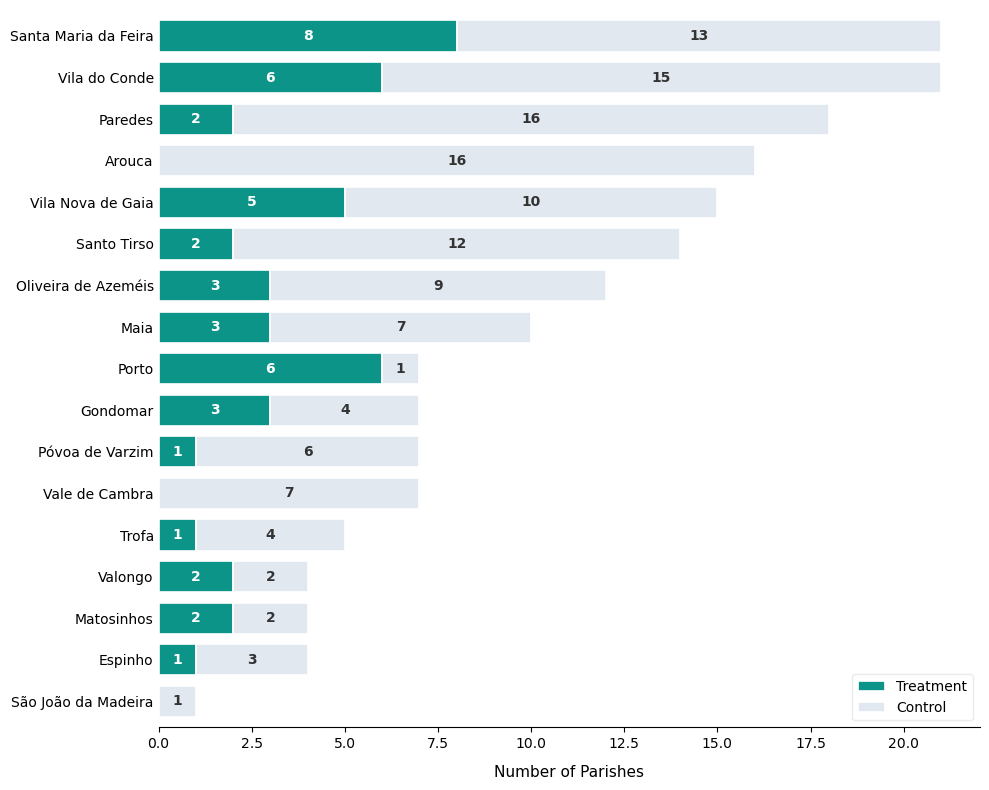

In [ ]:
# ============================================================
# 13.1 Parish distribution by municipality
# ============================================================

# 1. Prepaare the data
breakdown = pd.crosstab(
    parish_summary['municipality_name'], 
    parish_summary['control']
).rename(columns={True: 'Control', False: 'Treatment'})

for col in ['Treatment', 'Control']:
    if col not in breakdown.columns:
        breakdown[col] = 0

breakdown['Total'] = breakdown['Control'] + breakdown['Treatment']
# Sort by total parish number
breakdown = breakdown.sort_values(by=['Total', 'Treatment'], ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

plot_data = breakdown[['Treatment', 'Control']]
plot_data.plot(
    kind='barh', 
    stacked=True, 
    ax=ax, 
    color=['#0D9488', '#E2E8F0'], 
    width=0.75,
    edgecolor='white',
    linewidth=1.2
)

for container in ax.containers:
    labels = [f'{int(v)}' if v > 0 else '' for v in container.datavalues]
    # O texto fica branco nas barras escuras (Tratamento) e escuro nas claras (Controlo)
    color = 'white' if container.get_children()[0].get_facecolor()[0] < 0.5 else '#333333'
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold', color=color)

#ax.set_title("Distribuição do Painel de Freguesias por Município\n(Tratamento vs. Controlo)", 
 #            fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Number of Parishes", fontsize=11, labelpad=10)
ax.set_ylabel("") # Remove o label do eixo Y para ficar mais limpo

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0) # Remove os tracinhos do eixo Y

ax.legend(['Treatment', 'Control'], loc='lower right', frameon=True, facecolor='white', edgecolor='#E5E7EB')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_parish_distribution_stacked.png", dpi=300, bbox_inches="tight")
plt.show()


--- DEBUG: Unmatched Municipalities ---
These regions are missing data after the merge: ['AROUCA' 'SAO JOAO DA MADEIRA' 'VALE DE CAMBRA']
Check if they exist in `muni_valid_sorted` under a slightly different name.
---------------------------------------



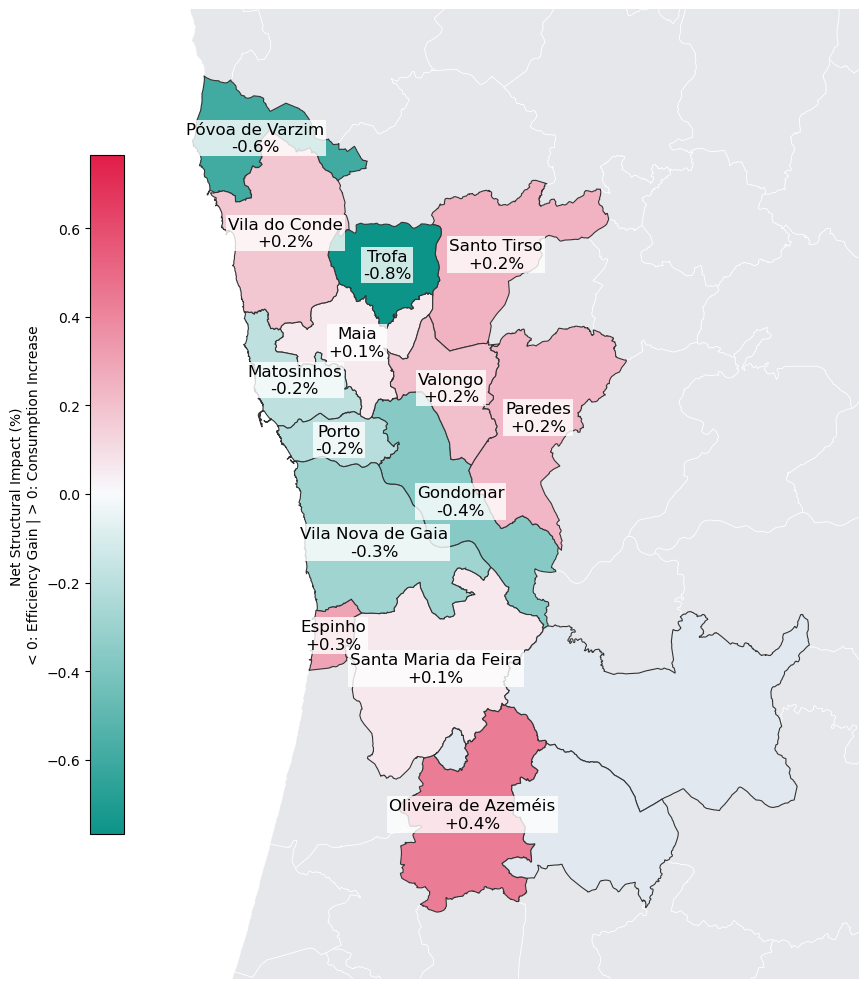

In [17]:
# ============================================================
# 13.2 Geospatial map of net structural impact
# ============================================================

# --- Helper Function for Text Normalization ---
def normalize_text(text):
    """Removes accents, converts to uppercase, and strips whitespace."""
    if pd.isna(text):
        return text
    normalized = ''.join(c for c in unicodedata.normalize('NFD', str(text)) 
                         if unicodedata.category(c) != 'Mn')
    return normalized.upper().strip()

# --- 1. Load and Dissolve Shapefile ---
regions = gpd.read_file("input/Continente_CAOP2025.gpkg", layer=3)

# Filter for the Porto Metropolitan Area
porto_regions = regions[regions['nuts3'] == 'Área Metropolitana do Porto'].copy()

# Dissolve parishes ('freguesia') into municipalities ('concelho')
muni_boundaries = porto_regions.dissolve(by='municipio').reset_index()

# --- 2. Data Merging ---
# Apply the normalization function to ensure strings match exactly regardless of accents
muni_boundaries['merge_name'] = muni_boundaries['municipio'].apply(normalize_text)

muni_plot_geo = muni_valid_sorted.copy()
muni_plot_geo['merge_name'] = muni_plot_geo['municipality_name'].apply(normalize_text)

# Merge the data
map_data = muni_boundaries.merge(muni_plot_geo, on='merge_name', how='left')

# --- Optional Debug: Check for any remaining unmatched municipalities ---
missing_munis = map_data[map_data['muni_net_true_impact'].isna()]['merge_name'].unique()
if len(missing_munis) > 0:
    print("\n--- DEBUG: Unmatched Municipalities ---")
    print(f"These regions are missing data after the merge: {missing_munis}")
    print("Check if they exist in `muni_valid_sorted` under a slightly different name.")
    print("---------------------------------------\n")

# --- 3. Custom Presentation Colormap ---
colors = ["#0D9488", "#F8FAFC", "#E11D48"]
cmap_impact = mcolors.LinearSegmentedColormap.from_list("ImpactCmap", colors)

# Handle potential cases where all data might be missing to avoid max() errors
if map_data['muni_net_true_impact'].notna().any():
    max_val = max(abs(map_data['muni_net_true_impact'].min()), abs(map_data['muni_net_true_impact'].max()))
    vmin, vmax = -max_val, max_val
else:
    vmin, vmax = -1, 1 # Fallback if entirely empty

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(10, 10))

# Base plot for all regions (background for missing data)
regions.plot(ax=ax, facecolor='#E5E7EB', edgecolor='#FFFFFF', linewidth=0.5)

# Plot the merged data
map_data.plot(
    column='muni_net_true_impact',
    ax=ax,
    cmap=cmap_impact,
    vmin=vmin,
    vmax=vmax,
    edgecolor='#333333',
    linewidth=0.8,
    legend=True,
    missing_kwds={'color': '#E2E8F0', 'label': 'No Data / Excluded'},
    legend_kwds={
        'label': "Net Structural Impact (%) \n< 0: Efficiency Gain | > 0: Consumption Increase",
        'location': "left",
        'shrink': 0.7,
        'pad': 0.02})

# Set zoom limits with margins
minx, miny, maxx, maxy = map_data.total_bounds
margin_x = (maxx - minx) * 0.08
margin_y = (maxy - miny) * 0.08
ax.set_xlim(minx - margin_x, maxx + margin_x)
ax.set_ylim(miny - margin_y, maxy + margin_y)

# Add text labels for valid data points
for idx, row in map_data.iterrows():
    if pd.notnull(row['muni_net_true_impact']):
        centroid = row['geometry'].centroid
        label_text = f"{row['municipality_name']}\n{row['muni_net_true_impact']:+.1f}%"
        ax.text(centroid.x, centroid.y, label_text,
                fontsize=12, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1.5))

ax.axis('off')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_B4_municipality_map.png", dpi=150, bbox_inches="tight")
plt.show()

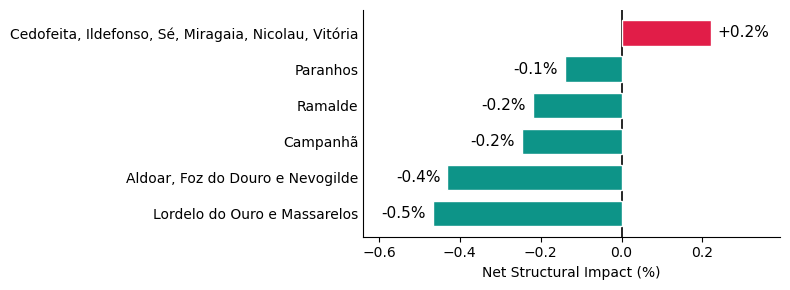

In [18]:
# ============================================================
# 13.3 Porto — parish net structural impact
# ============================================================

# Filter for Porto
porto_parishes = parish_summary[
    (parish_summary["municipality_name"] == "Porto") & 
    (~parish_summary["control"].astype(bool))
].copy()

# Compute net impact (bias-corrected)
porto_control_error = muni_summary.loc[
    muni_summary["municipality_name"] == "Porto", "muni_control_error_pct"
].values[0]

porto_parishes["parish_net_impact"] = (
    porto_parishes["deviation_pct"] - porto_control_error
)

porto_sorted = porto_parishes.sort_values("parish_net_impact").reset_index(drop=True)

colors = ["#0D9488" if v < 0 else "#E11D48" for v in porto_sorted["parish_net_impact"]]

fig, ax = plt.subplots(figsize=(8, max(3, len(porto_sorted) * 0.5)))
bars = ax.barh(
    porto_sorted["parish_name"],
    porto_sorted["parish_net_impact"],
    color=colors,
    edgecolor="white",
    height=0.7,
)

ax.axvline(0, color="black", linewidth=1.2, zorder=0)
labels = [f"{v:+.1f}%" for v in porto_sorted["parish_net_impact"]]
ax.bar_label(bars, labels=labels, padding=5, fontsize=11)
ax.margins(x=0.25, y=0.05)
ax.tick_params(axis="y", length=0)
#ax.set_title("Santa Maria da Feira — Parish Net Structural Impact", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Net Structural Impact (%)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_porto_parishes.png", dpi=150, bbox_inches="tight")
plt.show()

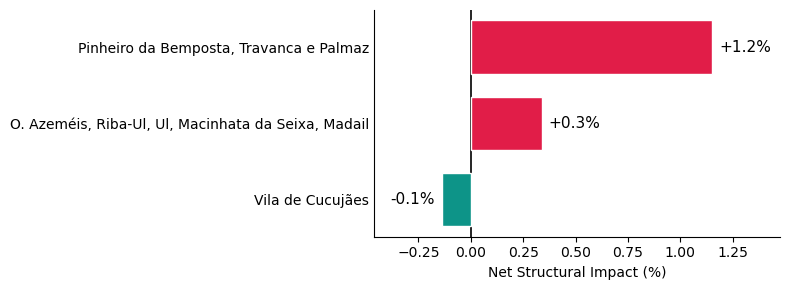

In [19]:
# ============================================================
# 13.4 Oliveira de Azeméis — parish net structural impact
# ============================================================

# Filter for Oliveira de Azeméis
oliveira_parishes = parish_summary[
    (parish_summary["municipality_name"] == "Oliveira de Azeméis") & 
    (~parish_summary["control"].astype(bool))
].copy()

# Compute net impact (bias-corrected)
oliveira_control_error = muni_summary.loc[
    muni_summary["municipality_name"] == "Oliveira de Azeméis", "muni_control_error_pct"
].values[0]

oliveira_parishes["parish_net_impact"] = (
    oliveira_parishes["deviation_pct"] - oliveira_control_error
)

oliveira_sorted = oliveira_parishes.sort_values("parish_net_impact").reset_index(drop=True)

colors = ["#0D9488" if v < 0 else "#E11D48" for v in oliveira_sorted["parish_net_impact"]]

fig, ax = plt.subplots(figsize=(8, max(3, len(oliveira_sorted) * 0.5)))
bars = ax.barh(
    oliveira_sorted["parish_name"],
    oliveira_sorted["parish_net_impact"],
    color=colors,
    edgecolor="white",
    height=0.7,
)

ax.axvline(0, color="black", linewidth=1.2, zorder=0)
labels = [f"{v:+.1f}%" for v in oliveira_sorted["parish_net_impact"]]
ax.bar_label(bars, labels=labels, padding=5, fontsize=11)
ax.margins(x=0.25, y=0.05)
ax.tick_params(axis="y", length=0)
#ax.set_title("Oliveira de Azeméis — Parish Net Structural Impact", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Net Structural Impact (%)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_oliveira_parishes.png", dpi=150, bbox_inches="tight")
plt.show()

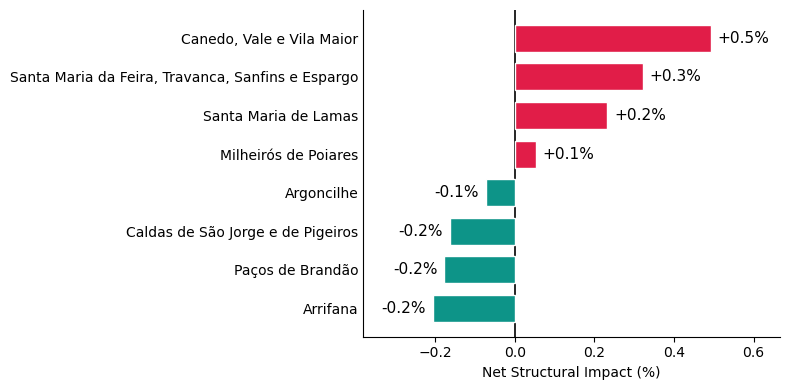

In [20]:
# ============================================================
# 13.5 Santa Maria da Feira — parish net structural impact
# ============================================================

# Filter for Santa Maria da Feira
santa_maria_parishes = parish_summary[
    (parish_summary["municipality_name"] == "Santa Maria da Feira") & 
    (~parish_summary["control"].astype(bool))
].copy()

# Compute net impact (bias-corrected)
santa_maria_control_error = muni_summary.loc[
    muni_summary["municipality_name"] == "Santa Maria da Feira", "muni_control_error_pct"
].values[0]

santa_maria_parishes["parish_net_impact"] = (
    santa_maria_parishes["deviation_pct"] - santa_maria_control_error
)

santa_maria_sorted = santa_maria_parishes.sort_values("parish_net_impact").reset_index(drop=True)

colors = ["#0D9488" if v < 0 else "#E11D48" for v in santa_maria_sorted["parish_net_impact"]]

fig, ax = plt.subplots(figsize=(8, max(3, len(santa_maria_sorted) * 0.5)))
bars = ax.barh(
    santa_maria_sorted["parish_name"],
    santa_maria_sorted["parish_net_impact"],
    color=colors,
    edgecolor="white",
    height=0.7,
)

ax.axvline(0, color="black", linewidth=1.2, zorder=0)
labels = [f"{v:+.1f}%" for v in santa_maria_sorted["parish_net_impact"]]
ax.bar_label(bars, labels=labels, padding=5, fontsize=11)
ax.margins(x=0.25, y=0.05)
ax.tick_params(axis="y", length=0)
#ax.set_title("Santa Maria da Feira — Parish Net Structural Impact", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Net Structural Impact (%)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_santa_maria_parishes.png", dpi=150, bbox_inches="tight")
plt.show()

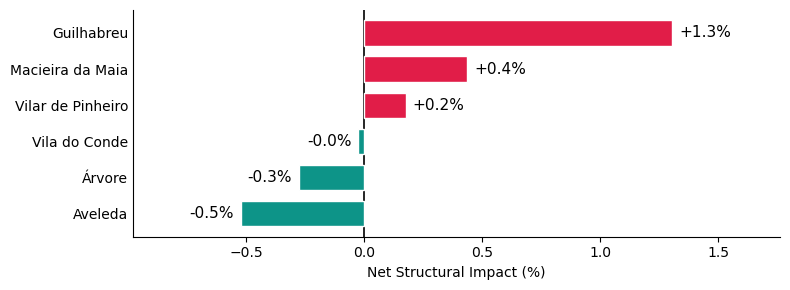

In [21]:
# ============================================================
# 13.6 Vila do Conde — parish net structural impact
# ============================================================

# Filter for Vila do Conde
conde_parishes = parish_summary[
    (parish_summary["municipality_name"] == "Vila do Conde") & 
    (~parish_summary["control"].astype(bool))
].copy()

# Compute net impact (bias-corrected)
conde_control_error = muni_summary.loc[
    muni_summary["municipality_name"] == "Vila do Conde", "muni_control_error_pct"
].values[0]

conde_parishes["parish_net_impact"] = (
    conde_parishes["deviation_pct"] - conde_control_error
)

conde_sorted = conde_parishes.sort_values("parish_net_impact").reset_index(drop=True)

colors = ["#0D9488" if v < 0 else "#E11D48" for v in conde_sorted["parish_net_impact"]]

fig, ax = plt.subplots(figsize=(8, max(3, len(conde_sorted) * 0.5)))
bars = ax.barh(
    conde_sorted["parish_name"],
    conde_sorted["parish_net_impact"],
    color=colors,
    edgecolor="white",
    height=0.7,
)

ax.axvline(0, color="black", linewidth=1.2, zorder=0)
labels = [f"{v:+.1f}%" for v in conde_sorted["parish_net_impact"]]
ax.bar_label(bars, labels=labels, padding=5, fontsize=11)
ax.margins(x=0.25, y=0.05)
ax.tick_params(axis="y", length=0)
#ax.set_title("Vila do Conde — Parish Net Structural Impact", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Net Structural Impact (%)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_conde_parishes.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Treatment Timeline and Heterogeneity

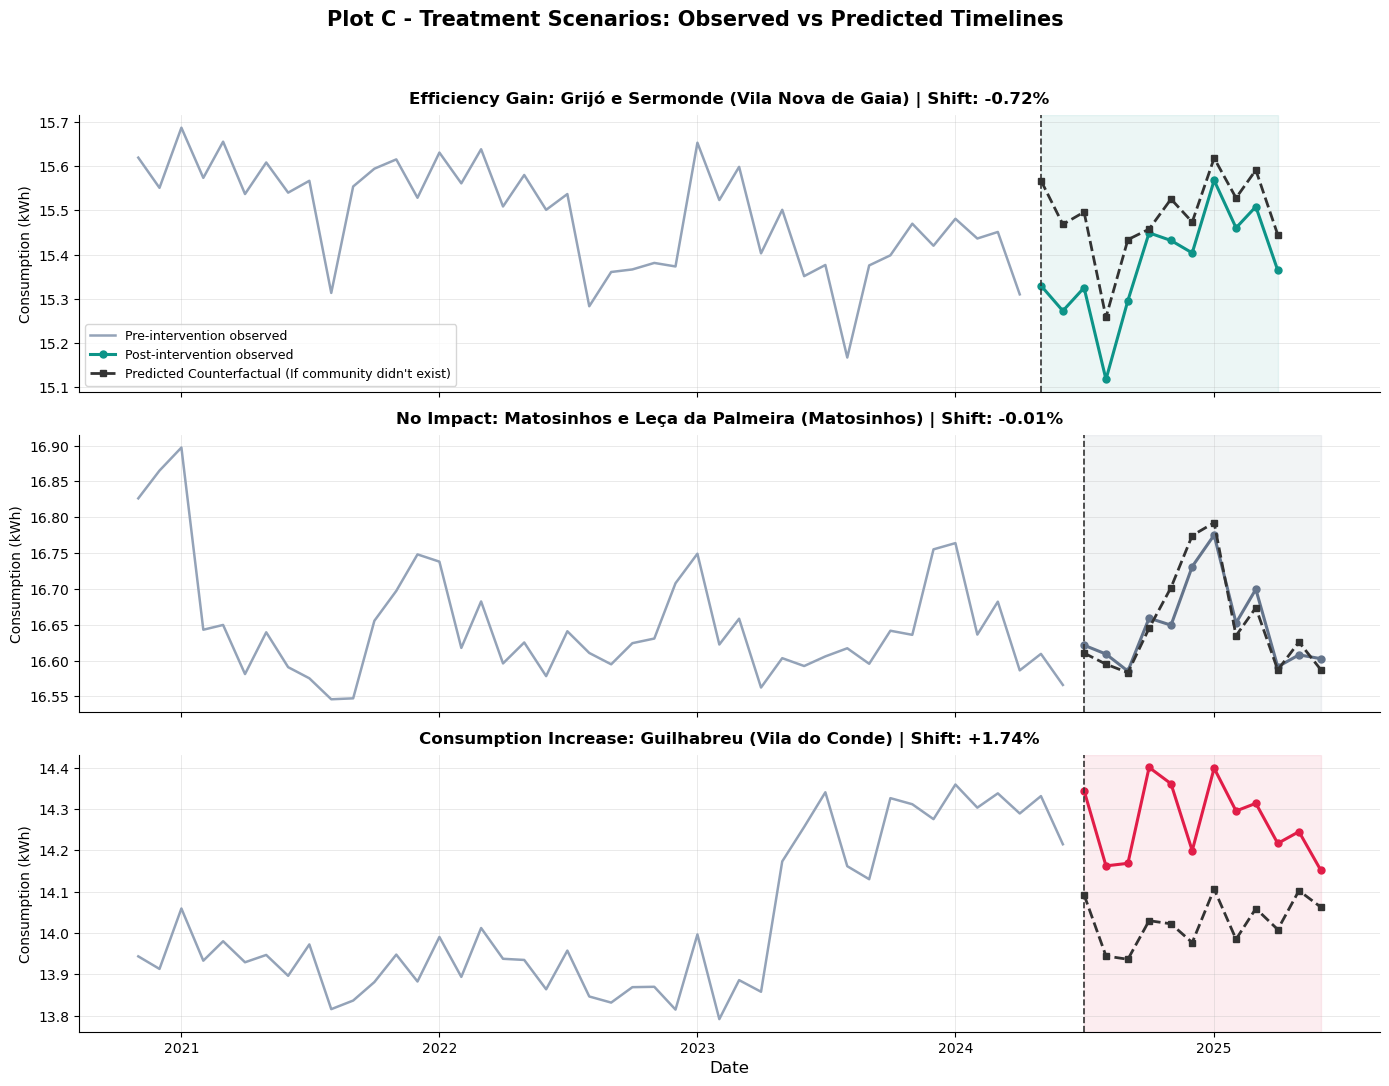

Scenarios plotted:
 - Best   : Grijó e Sermonde (-0.72%)
 - Neutral: Matosinhos e Leça da Palmeira (-0.01%)
 - Worst  : Guilhabreu (+1.74%)


In [22]:
# ============================================================
# 14.1 Treatment timelines (best, neutral, worst)
# ============================================================
valid_parishes = []
treatment_parishes = parish_summary.loc[~parish_summary["control"].astype(bool), "parish_code"].unique()

for code in treatment_parishes:
    if (df_before["parish_code"] == code).any() and (df_after_enr["parish_code"] == code).any():
        valid_parishes.append(code)

valid_pool = parish_summary[parish_summary["parish_code"].isin(valid_parishes)].copy()

if len(valid_pool) < 3:
    print("Not enough valid treatment parishes to plot 3 scenarios.")
else:
    valid_pool = valid_pool.sort_values("deviation_pct")
    best_parish = valid_pool.iloc[0]
    worst_parish = valid_pool.iloc[-1]
    valid_pool["abs_dist_zero"] = valid_pool["deviation_pct"].abs()
    neutral_parish = valid_pool.sort_values("abs_dist_zero").iloc[0]

    scenarios = [
        ("Efficiency Gain", best_parish, "#0D9488"),
        ("No Impact", neutral_parish, "#64748B"),
        ("Consumption Increase", worst_parish, "#E11D48")    ]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10.5), sharex=True)

    for ax, (label, row, color) in zip(axes, scenarios):
        code_ = row["parish_code"]
        obs_impact = row["deviation_pct"]
        pre = df_before[df_before["parish_code"] == code_].sort_values("date")
        post = df_after_enr[df_after_enr["parish_code"] == code_].sort_values("date")
        parish_name = post["parish_name"].iloc[0] if "parish_name" in post.columns else str(code_)
        muni_name = post["municipality_name"].iloc[0] if "municipality_name" in post.columns else ""
        intervention_date = post["date"].min()

        ax.plot(pre["date"], pre[TARGET], color="#94a3b8", linewidth=1.8,
                label="Pre-intervention observed")
        ax.plot(post["date"], post[TARGET], color=color, linewidth=2.2,
                marker="o", markersize=5, label="Post-intervention observed")
        ax.plot(post["date"], post["pred_ensemble"], color="#333333",
                linewidth=2.0, marker="s", markersize=4, linestyle="--",
                label="Predicted Counterfactual (If community didn't exist)")

        ax.axvline(intervention_date, color="#333333", linestyle="--", linewidth=1.2)
        ax.axvspan(intervention_date, post["date"].max(), color=color, alpha=0.08)

        ax.set_title(
            f"{label}: {parish_name} ({muni_name}) | Shift: {obs_impact:+.2f}%",
            fontsize=12, fontweight="bold", pad=8        )
        ax.set_ylabel("Consumption (kWh)")
        ax.grid(alpha=0.3)
        if ax == axes[0]:
            ax.legend(loc="lower left", fontsize=9, frameon=True)

    axes[-1].set_xlabel("Date", fontsize=12)
    fig.suptitle("Plot C - Treatment Scenarios: Observed vs Predicted Timelines",
                 fontsize=15, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/plot_C_treatment_scenarios.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Scenarios plotted:")
    print(f" - Best   : {best_parish['parish_name']} ({best_parish['deviation_pct']:+.2f}%)")
    print(f" - Neutral: {neutral_parish['parish_name']} ({neutral_parish['deviation_pct']:+.2f}%)")
    print(f" - Worst  : {worst_parish['parish_name']} ({worst_parish['deviation_pct']:+.2f}%)")

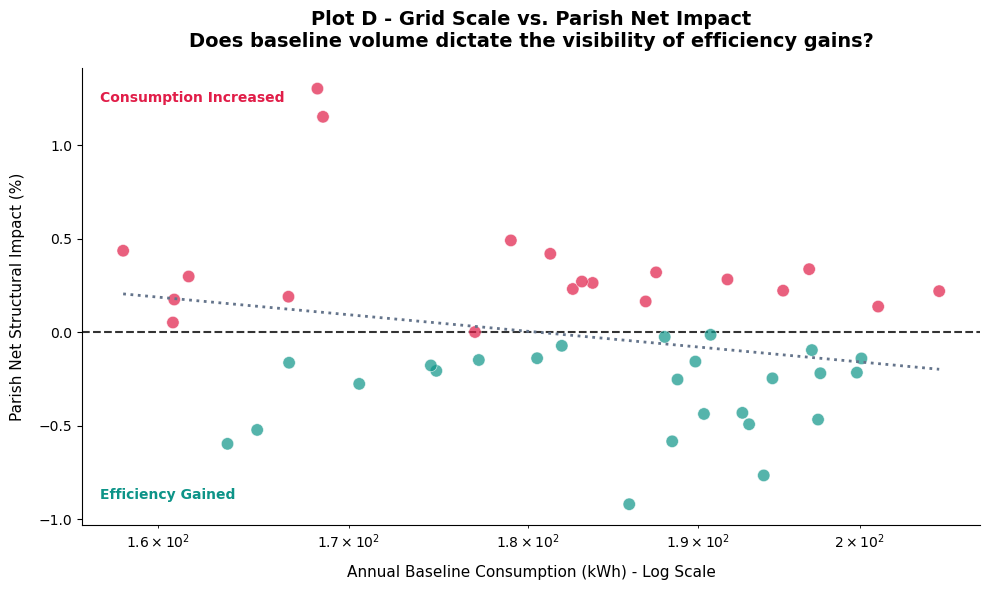

Correlation (Log Scale): -0.257
Insight: Negative correlation. Larger parishes actually show better savings percentages.


In [23]:
# ============================================================
# 14.2 Grid scale vs net impact (heterogeneity)
# ============================================================

# --- 1. Prepare Data ---
treatment_df = parish_summary[~parish_summary["control"].astype(bool)].copy()
muni_bias_map = muni_summary.set_index("municipality_name")["muni_control_error_pct"].to_dict()
treatment_df["muni_control_error_pct"] = treatment_df["municipality_name"].map(muni_bias_map)
treatment_df["parish_net_impact"] = treatment_df["deviation_pct"] - treatment_df["muni_control_error_pct"]
treatment_df["annual_predicted_kwh"] = treatment_df["predicted_mean"] * 12
analysis_df = treatment_df.dropna(subset=["annual_predicted_kwh", "parish_net_impact"]).copy()

# --- 2. Build the Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#0D9488" if v < 0 else "#E11D48" for v in analysis_df["parish_net_impact"]]
ax.axhline(0, color="#333333", linestyle="--", linewidth=1.5, zorder=1)
ax.scatter(
    analysis_df["annual_predicted_kwh"],
    analysis_df["parish_net_impact"],
    c=colors, s=80, alpha=0.7, edgecolor="white", linewidth=0.5, zorder=2)
sns.regplot(
    data=analysis_df, x="annual_predicted_kwh", y="parish_net_impact",
    scatter=False, color="#64748B", line_kws={"linewidth": 2, "linestyle": ":"},
    ax=ax, ci=None, logx=True)

ax.set_title("Plot D - Grid Scale vs. Parish Net Impact\nDoes baseline volume dictate the visibility of efficiency gains?",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Annual Baseline Consumption (kWh) - Log Scale", fontsize=11, labelpad=10)
ax.set_ylabel("Parish Net Structural Impact (%)", fontsize=11, labelpad=10)
ax.set_xscale("log")

def format_kwh(x, pos):
    if x >= 1e6: return f'{x*1e-6:g}M'
    if x >= 1e3: return f'{x*1e-3:g}k'
    return f'{x:g}'
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_kwh))

ax.text(0.02, 0.95, "Consumption Increased", transform=ax.transAxes,
        color="#E11D48", fontsize=10, fontweight="bold", va="top")
ax.text(0.02, 0.05, "Efficiency Gained", transform=ax.transAxes,
        color="#0D9488", fontsize=10, fontweight="bold", va="bottom")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_D_grid_scale.png", dpi=150, bbox_inches="tight")
plt.show()

corr = np.corrcoef(np.log(analysis_df["annual_predicted_kwh"]), analysis_df["parish_net_impact"])[0, 1]
print(f"Correlation (Log Scale): {corr:.3f}")
if corr > 0.2:
    print("Insight: Positive correlation. As parish volume gets larger, the percentage savings shrink toward zero (or turn positive). The signal gets swallowed by grid noise.")
elif corr < -0.2:
    print("Insight: Negative correlation. Larger parishes actually show better savings percentages.")
else:
    print("Insight: Weak correlation. The grid footprint size does not explain the variance between successful and unsuccessful parishes.")